# Module 9 — The Tropospheric Ozone Budget, Carbonyls and NOx Reservoirs
### B4 Chemistry in the Atmosphere · companion notebook

Covers: the global O3 budget sensitivity (Table 3.2), PAN steady-state decomposition kinetics,
and a simple night-time NO3/N2O5 reservoir model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## The tropospheric ozone budget (Table 3.2)

Gross production and loss are much larger than the net terms. We explore how sensitive the
*net* trend is to small percentage errors/changes in the large gross terms.

In [2]:
strat_input = 400     # Tg/yr
chem_prod = 4000       # Tg/yr
chem_loss = 3200       # Tg/yr
surface_loss = 1200    # Tg/yr

net_chem = chem_prod - chem_loss
net_budget = strat_input + net_chem - surface_loss
print(f"Net chemical term: {net_chem} Tg/yr")
print(f"Overall net budget (should be ~0 in steady state): {net_budget} Tg/yr")

# Sensitivity: what if chemical production is off by +/- 5%?
for pct in [-0.05, -0.02, 0, 0.02, 0.05]:
    perturbed_prod = chem_prod * (1+pct)
    perturbed_net = strat_input + (perturbed_prod - chem_loss) - surface_loss
    print(f"  chem_prod {pct:+.0%}: net budget = {perturbed_net:+.0f} Tg/yr "
          f"({100*perturbed_net/300:.1f}% of the ~300 Tg burden per year)")

Net chemical term: 800 Tg/yr
Overall net budget (should be ~0 in steady state): 0 Tg/yr
  chem_prod -5%: net budget = -200 Tg/yr (-66.7% of the ~300 Tg burden per year)
  chem_prod -2%: net budget = -80 Tg/yr (-26.7% of the ~300 Tg burden per year)
  chem_prod +0%: net budget = +0 Tg/yr (0.0% of the ~300 Tg burden per year)
  chem_prod +2%: net budget = +80 Tg/yr (26.7% of the ~300 Tg burden per year)
  chem_prod +5%: net budget = +200 Tg/yr (66.7% of the ~300 Tg burden per year)


A +/-5% error in the *gross* chemical production term (4000 Tg/yr) swings the *net* budget
by +/-200 Tg/yr -- comparable to the entire tropospheric ozone burden (~300 Tg). This is exactly
the point made in the notes: because gross terms are so much larger than net terms, ozone burden
trends are very sensitive to small systematic errors or real changes in the chemical terms.

## PAN steady-state decomposition rate

$$k = k_{3.20}\left\{1 - \frac{1}{1+\dfrac{k_{3.21}[NO]}{k_{3.19}[NO_2]}}\right\}$$

$$k_{3.20} = 4.0\times10^{15}\exp\{-108/RT\}\ \text{s}^{-1} \quad (E_a\text{ in kJ/mol})$$

In [3]:
R = 8.314e-3   # kJ/mol/K

def k_3_20(T):
    return 4.0e15 * np.exp(-108/(R*T))

def PAN_decomposition_rate(NO, NO2, T, k_3_19=1e-11, k_3_21=1e-11):
    k20 = k_3_20(T)
    ratio = k_3_21*NO / (k_3_19*NO2)
    return k20 * (1 - 1/(1+ratio))

# Boundary layer daytime: NO and NO2 both present, T ~ 298 K
k_bl_day = PAN_decomposition_rate(NO=1e9, NO2=2e9, T=298)
tau_bl_day_hr = 1/k_bl_day/3600
print(f"Boundary layer, daytime: k = {k_bl_day:.3e} s^-1, tau = {tau_bl_day_hr:.2f} hours")

# Boundary layer at night: NO ~ 0
k_bl_night = PAN_decomposition_rate(NO=1e2, NO2=2e9, T=290)
tau_bl_night_hr = 1/k_bl_night/3600
print(f"Boundary layer, night ([NO]~0): tau = {tau_bl_night_hr:.1f} hours (should be very long)")

# Upper troposphere: cold, T ~ 230 K
k_ut = PAN_decomposition_rate(NO=1e8, NO2=2e8, T=230)
tau_ut_days = 1/k_ut/86400
print(f"Upper troposphere (T=230K): tau = {tau_ut_days:.1f} days")

Boundary layer, daytime: k = 1.562e-04 s^-1, tau = 1.78 hours
Boundary layer, night ([NO]~0): tau = 39470308.9 hours (should be very long)
Upper troposphere (T=230K): tau = 29309.2 days


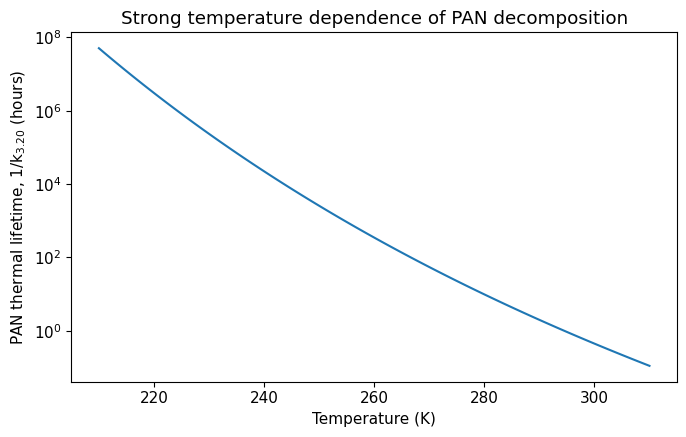

In [4]:
T_range = np.linspace(210, 310, 100)
k20_vals = k_3_20(T_range)
tau_vals_hr = 1/k20_vals/3600

plt.figure()
plt.semilogy(T_range, tau_vals_hr)
plt.xlabel('Temperature (K)')
plt.ylabel('PAN thermal lifetime, 1/k$_{3.20}$ (hours)')
plt.title('Strong temperature dependence of PAN decomposition')
plt.tight_layout()
plt.show()

## A simple night-time NO3/N2O5 reservoir model

$$\frac{d[NO_3]}{dt} = k_{3.22}[O_3][NO_2] - k_{3.23}[NO_3][NO_2][M] - k_{3.26}[NO_3][NO]$$
$$\frac{d[N_2O_5]}{dt} = k_{3.23}[NO_3][NO_2][M] - k_{diss}[N_2O_5] - k_{3.27}[N_2O_5]\{H_2O_{surf}\}$$

We integrate a simplified version overnight to see how much NOx ends up sequestered as HNO3
(via N2O5 + H2O -> 2HNO3) under different residual [NO] scenarios (R3.26 competition).

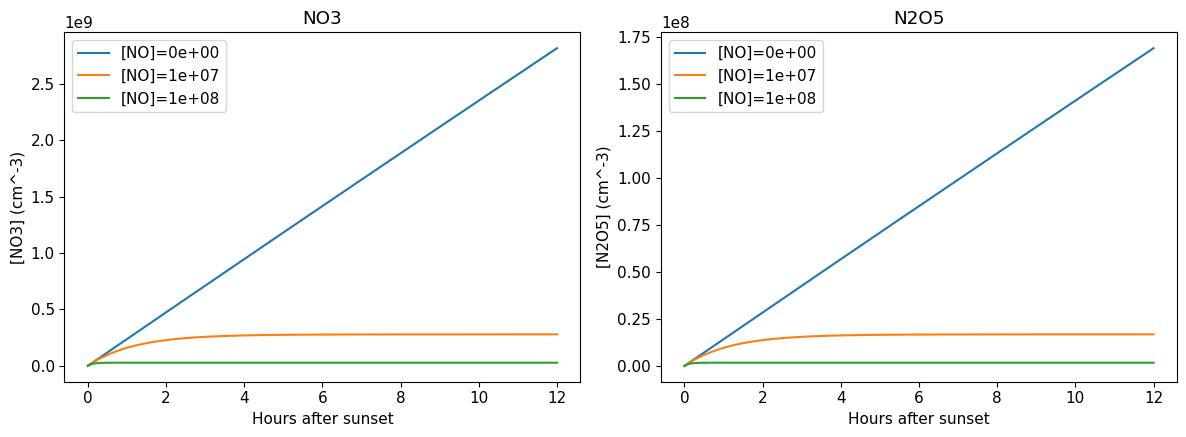

Even a small residual [NO] substantially suppresses NO3/N2O5 buildup (R3.26 competition),
consistent with the notes' point that this reaction competes with N2O5 formation near NO sources.


In [5]:
from scipy.integrate import odeint

k_3_22 = 3.5e-17    # cm^3/s, O3+NO2 -> NO3+O2 (order-of-magnitude, T~290K)
k_3_23_f = 1.5e-12  # NO3+NO2+M -> N2O5 (pseudo-2nd order, illustrative)
k_diss = 5e-2       # N2O5 -> NO3+NO2, illustrative overall dissociation rate, s^-1
k_3_26 = 2.5e-11    # NO3+NO -> 2NO2
k_3_27_eff = 1e-5   # effective pseudo-first-order N2O5 + H2O(surface) -> 2HNO3, s^-1 (aerosol-dependent)

O3 = 1e12    # molecules/cm^3, ~40 ppb
NO2 = 2e9    # molecules/cm^3, moderately polluted

def night_system(y, t, NO):
    NO3, N2O5 = y
    dNO3 = k_3_22*O3*NO2 - k_3_23_f*NO3*NO2 - k_3_26*NO3*NO - k_diss*0  # (N2O5 dissociation feeds back below)
    dNO3 += k_diss*N2O5
    dN2O5 = k_3_23_f*NO3*NO2 - k_diss*N2O5 - k_3_27_eff*N2O5
    return [dNO3, dN2O5]

t = np.linspace(0, 12*3600, 500)   # a 12-hour night

fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
for NO_resid in [0, 1e7, 1e8]:
    sol = odeint(night_system, [0,0], t, args=(NO_resid,))
    NO3, N2O5 = sol.T
    ax[0].plot(t/3600, NO3, label=f'[NO]={NO_resid:.0e}')
    ax[1].plot(t/3600, N2O5, label=f'[NO]={NO_resid:.0e}')

ax[0].set_xlabel('Hours after sunset'); ax[0].set_ylabel('[NO3] (cm^-3)'); ax[0].legend(); ax[0].set_title('NO3')
ax[1].set_xlabel('Hours after sunset'); ax[1].set_ylabel('[N2O5] (cm^-3)'); ax[1].legend(); ax[1].set_title('N2O5')
plt.tight_layout()
plt.show()

print("Even a small residual [NO] substantially suppresses NO3/N2O5 buildup (R3.26 competition),")
print("consistent with the notes' point that this reaction competes with N2O5 formation near NO sources.")

## Exercises

1. **HNO3 yield overnight.** Integrate `k_3_27_eff * N2O5` over the 12-hour window for each [NO]
   scenario above to estimate total HNO3 (and hence NOx) sequestered overnight. How much does
   residual [NO] change the total?

2. **PAN as regional NOx transport.** Using the boundary-layer vs. upper-troposphere PAN
   lifetimes you calculated, estimate how far PAN could be transported (in km) at a typical
   upper-tropospheric wind speed of ~20 m/s before half of it decomposes. Compare to typical
   synoptic-scale transport distances.

3. **Sensitivity of the ozone budget net.** Repeat the Table 3.2 sensitivity calculation, but
   perturbing `chem_loss` instead of `chem_prod`, and then `surface_loss`. Which term's
   uncertainty matters most for closing the tropospheric ozone budget?